### **1. Understand the data, and Setup**

In [1]:
#Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer


from sklearn.pipeline import Pipeline #pipeline

from sklearn.model_selection import( train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
  ) 

#Data preprocessing
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

#Classification models to try
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from sklearn.svm import SVC

from sklearn.tree import DecisionTreeClassifier

from sklearn.neighbors import KNeighborsClassifier

from sklearn.naive_bayes import BernoulliNB   

from xgboost import XGBClassifier

from joblib import dump

import func as prep_func

from imblearn.over_sampling import SMOTE






#Evaluation metrics
from sklearn.metrics import(
    classification_report,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score
)


In [2]:
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
sns.set_theme(style="darkgrid")

TARGET_COL = "Churn"
CSV_PATH = r"C:\Users\HP\Desktop\MY PROJECTS\Telco_cust_churn\WA_Fn-UseC_-Telco-Customer-Churn.csv"
RANDOM_STATE = 42

**PLAN OF ACTION**
- Load Data, Check Target Distributions, Check Data Info, Check Data Description, Make Inferences
- EDA and visualization, Target column, numeric column, categorical columns
- Data Preprocessing, train test split, make pipelines for preprocessing 
- Baseline Model pipeline, training, testing, evaluation
- Model Selection and Training,
- Hyperparameter Tuning
- Retrain the model with the best parameters
- Create a predictive system
- Test the predictive system
- Save the trained model using dump

### **2. Load Data**

In [3]:
df = pd.read_csv(CSV_PATH)


**ID column does not affect predictions, so would be removed**

In [4]:
df = df.drop(columns=["customerID"])

In [5]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.5,No


In [6]:
df.tail(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.400,306.6,Yes
7042,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.650,6844.5,No


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.000,0.162,0.369,0.000,0.000,0.000,0.000,1.000
tenure,7043.000,32.371,24.559,0.000,9.000,29.000,55.000,72.000
MonthlyCharges,7043.000,64.762,30.090,18.250,35.500,70.350,89.850,118.750


**TotalCharges should be numeric but it appears to be a string, analyze the column a bit more**

### 3. EDA and visualization

In [9]:
df.columns.tolist()

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [10]:
numerical_cols = []
non_numerical_cols = []

for col in df.columns:
    if df[col].nunique() <= 10: #Categorical columns
        non_numerical_cols.append(col)
    else:
        numerical_cols.append(col)#get the proper numerical columns

# print(df.nunique())

print("Numerical Columns: ", numerical_cols, "\nLength: ",len(numerical_cols))
print("Non numerical columns: ", non_numerical_cols, "\nLength: ", len(non_numerical_cols))

# print(df["TotalCharges"].dtype)

Numerical Columns:  ['tenure', 'MonthlyCharges', 'TotalCharges'] 
Length:  3
Non numerical columns:  ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'] 
Length:  17


In [11]:
df.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [12]:
for col in df.columns:
    print(df[col].value_counts().head(5))

gender
Male      3555
Female    3488
Name: count, dtype: int64
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
tenure
1     613
72    362
2     238
3     200
4     176
Name: count, dtype: int64
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64
TechSupport
No      

- Multiple binary categorical columns
- Presence of nominal columns as well
- target column is imbalanced[Must consider this when creating models, class_weight should be balanced]
- TargetColumn is suspicious

In [13]:
#check Target Column
df["TotalCharges"].value_counts()

TotalCharges
20.2       11
           11
19.75       9
19.9        8
20.05       8
19.65       8
45.3        7
19.55       7
20.15       6
19.45       6
20.25       6
20.45       5
20.3        5
74.7        4
70.6        4
44          4
75.3        4
20.4        4
19.85       4
49.9        4
44.4        4
69.9        4
20.35       4
50.15       4
69.6        4
19.5        4
19.2        4
69.95       4
19.3        4
19.4        4
20.5        4
19.95       4
69.65       4
70.45       3
24.8        3
84.5        3
25.25       3
80.55       3
19.25       3
69.55       3
74.35       3
85          3
45.7        3
74.6        3
35.9        3
220.45      3
20          3
2317.1      3
470.2       3
74.9        3
45.85       3
86.05       3
69.25       3
50.45       3
20.55       3
44.75       3
45.1        3
20.9        3
75.35       3
74.3        3
383.65      3
1284.2      3
85.5        3
70.15       3
50.6        3
305.55      3
70.1        3
55.7        3
79.55       3
19.1        3
20.1   

**In the TotalCharges Column, there are empty spaces, this should be not so**

In [14]:
#Converts the column to be numeric and then makes the empty spaces to be NaNs
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].dtype


dtype('float64')

In [15]:
#recheck distribution
df.isna().sum()#Total charges null values have been displayed

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

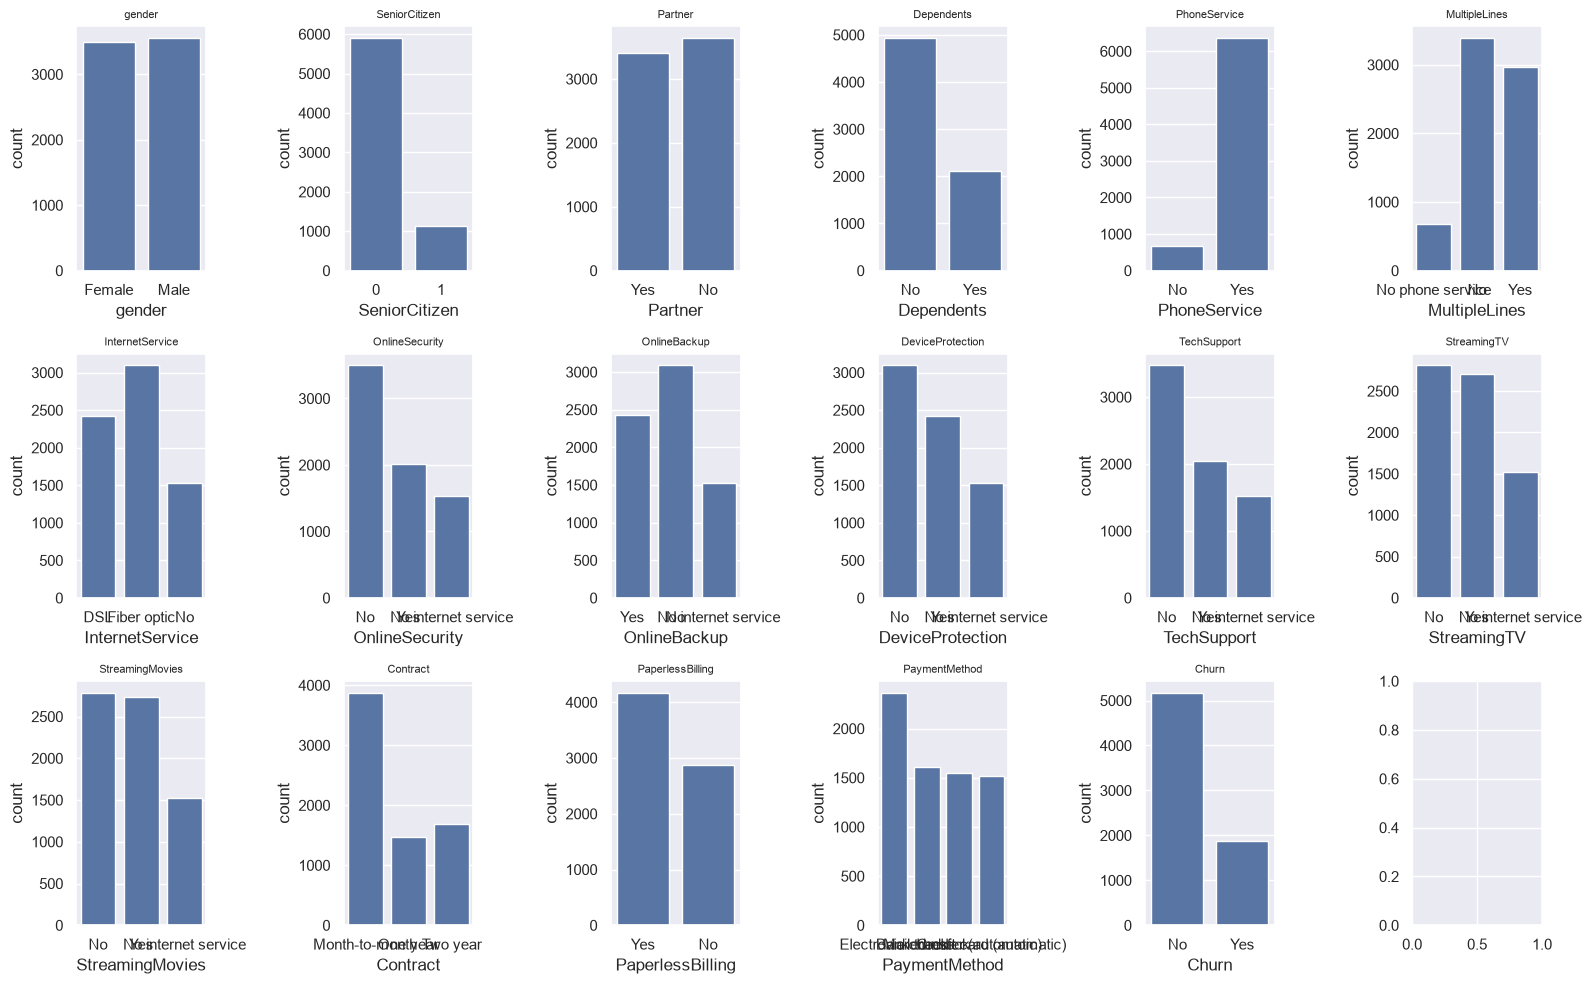

In [16]:
#See non numerical columns distribution
fig, axes = plt.subplots(3, 6, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(non_numerical_cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

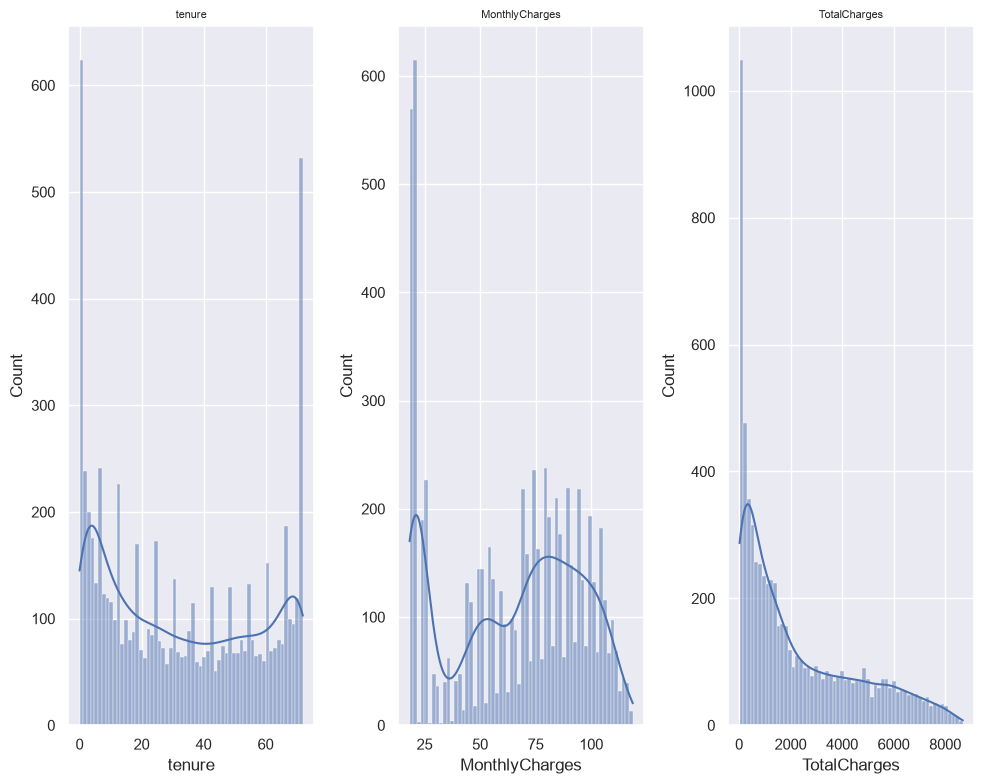

In [17]:
#numerical columns distribution
fig, axes = plt.subplots(1, 3, figsize=(10, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(data=df, x=col, ax=axes[i], kde=True, bins=60)
    axes[i].set_title(col, fontsize=8)
    

plt.tight_layout()
plt.show()

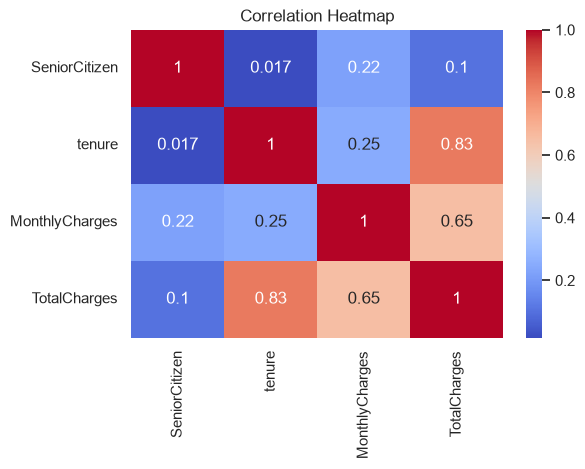

In [18]:
#Still visualize a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**Tenure and Total Charges are correlated**

In [19]:
#check for duplicates
duplicated_mask = df.duplicated()
num_duplicated = duplicated_mask.sum()

print("Number of duplicate rows: ", num_duplicated)

Number of duplicate rows:  22


In [20]:
#Drop duplicate rows
df = df.drop_duplicates()

In [21]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

### **4. Data Preprocessing**

In [22]:
X= df.drop(columns=TARGET_COL)
y=df[TARGET_COL]


In [23]:
X[:5]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.850
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.500
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.150
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,1840.750
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.650


In [24]:
y[:5]

0     No
1     No
2    Yes
3     No
4    Yes
Name: Churn, dtype: str

In [25]:
y = y.map({"No": 0, "Yes": 1})

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

In [27]:
print("X_train shape", X_train.shape)
print("X_test shape: ", X_test.shape)

X_train shape (5616, 19)
X_test shape:  (1405, 19)


In [28]:
y_train[:5]

2629    1
2650    0
1418    0
5774    0
2425    0
Name: Churn, dtype: int64

**Note that the senior citizen column is already encoded**

In [29]:
binary_features = []#Use a function
nominal_features = []#OneHotEncoding
numeric_features = []#scaling

COL_WITH_ZEROS = ["TotalCharges"]

for col in X_train.columns.tolist():
    num_unique_values = X_train[col].nunique()
    if num_unique_values == 2:
        binary_features.append(col)
    elif num_unique_values > 2 and num_unique_values < 10:
        nominal_features.append(col)
    else:
        numeric_features.append(col)


binary_features.remove("SeniorCitizen")#Already encoded


print("BINARY FEATURES: ", binary_features)
print("NOMINAL FEATURES: ", nominal_features)
print("NUMERICAL FEATURES: ",numeric_features)

BINARY FEATURES:  ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
NOMINAL FEATURES:  ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
NUMERICAL FEATURES:  ['tenure', 'MonthlyCharges', 'TotalCharges']


In [30]:
for col in numeric_features:
    print(df[col].value_counts())

tenure
1     591
72    362
2     238
3     200
4     176
71    170
5     133
7     131
8     123
70    119
9     119
12    117
10    116
6     110
13    109
68    100
11     99
15     99
67     98
18     97
69     95
24     94
22     90
66     89
35     88
17     87
23     85
16     80
52     80
64     80
56     80
25     79
26     79
60     76
65     76
61     76
14     76
46     74
19     73
30     72
27     72
63     72
29     72
20     71
62     70
41     70
53     70
32     69
47     68
50     68
54     68
51     68
58     67
49     66
34     65
43     65
31     65
42     65
37     65
57     65
48     64
55     64
33     64
40     64
21     63
45     61
59     60
38     59
28     57
39     56
44     51
36     50
0      11
Name: count, dtype: int64
MonthlyCharges
20.050     59
19.850     45
19.950     44
19.700     43
19.900     43
20.000     43
19.650     42
20.150     39
19.750     39
20.250     39
19.550     39
19.800     38
20.350     38
19.600     37
20.100     36
20.200     3

In [31]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.850,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.500,No


In [32]:
zero_to_nan  = FunctionTransformer(
    prep_func.replace_zeros_with_nan_df,
    kw_args={"cols": COL_WITH_ZEROS},
    validate=False #Trust me bro
)

encode_binary = FunctionTransformer(
    prep_func.encode_binary_cols,
    kw_args={"cols": binary_features},
    validate=False
)


binary_transformer = Pipeline(
    steps = [
    ("encode", encode_binary),
    ]
)

nominal_transformer = Pipeline(
    steps = [
    ("oneHot", OneHotEncoder())
    ]
)

numerical_transformer = Pipeline(
    steps = [
    ("zero_to_nan", zero_to_nan),
    ("impute", SimpleImputer(strategy="median")), 
    ("scale", StandardScaler())
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("binary", binary_transformer, binary_features),
        ("nominal", nominal_transformer, nominal_features),
        ("numerical", numerical_transformer, numeric_features)
    ]
)

### **5. Baseline Model**

In [33]:
baseline_pipe = Pipeline(
    steps = [
        ("preprocess", preprocess),
        ("model", LogisticRegression(
            random_state=RANDOM_STATE,
            class_weight="balanced"
        ))
    ]
)

In [34]:
#train the model
baseline_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('binary', ...), ('nominal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rem

In [35]:
#attempt to predict
baseline_logreg_pred_train = baseline_pipe.predict(X_train)
baseline_logreg_pred_test = baseline_pipe.predict(X_test)

In [36]:
prep_func.print_evaluation("BASELINE MODEL(Logistic Regression) TRAINING EVALUATION", y_train,baseline_logreg_pred_train)

BASELINE MODEL(Logistic Regression) TRAINING EVALUATION
ACCURACY SCORE: 75.0%
CLASSIFICATION REPORT: 
              precision    recall  f1-score   support

           0       0.92      0.73      0.81      4131
           1       0.52      0.81      0.63      1485

    accuracy                           0.75      5616
   macro avg       0.72      0.77      0.72      5616
weighted avg       0.81      0.75      0.76      5616



In [37]:
prep_func.print_evaluation("BASELINE MODEL(Logistic Regression) TESTING EVALUATION", y_test,baseline_logreg_pred_test)

BASELINE MODEL(Logistic Regression) TESTING EVALUATION
ACCURACY SCORE: 73.80799999999999%
CLASSIFICATION REPORT: 
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1033
           1       0.50      0.78      0.61       372

    accuracy                           0.74      1405
   macro avg       0.70      0.75      0.71      1405
weighted avg       0.80      0.74      0.75      1405



### 6. Model Selection

In [38]:
# scale_pos_weight = (# negative samples) / (# positive samples)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 2.7818181818181817


In [39]:
k = 10
cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

In [40]:
from sklearn.metrics import get_scorer_names
print(get_scorer_names())

['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'average_precision', 'balanced_accuracy', 'completeness_score', 'd2_absolute_error_score', 'd2_brier_score', 'd2_log_loss_score', 'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score', 'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples', 'jaccard_weighted', 'matthews_corrcoef', 'mutual_info_score', 'neg_brier_score', 'neg_log_loss', 'neg_max_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'neg_negative_likelihood_ratio', 'neg_root_mean_squared_error', 'neg_root_mean_squared_log_error', 'normalized_mutual_info_score', 'positive_likelihood_ratio', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'r2', 'rand_score', 'recall', 'recall_m

In [41]:
models = {
    "LogisticRegression": LogisticRegression(
        random_state=RANDOM_STATE,
        class_weight="balanced",
        max_iter=1000
    ),
    "RandomForest": RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced_subsample"
    ),
    "HistGB": HistGradientBoostingClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ),
    "SVC": SVC(
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ),
    "DecisionTree": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ),
    "XGB": XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss"
    ),
    "naiveBayes": BernoulliNB(
    alpha=1.0,           # Laplace Smoothing
    binarize=0.0,        # The threshold to convert continuous data into binary
    fit_prior=True       # Accounts for class imbalance
    )
}

scoring = {
    "accuracy": "accuracy",
    "recall": "recall",
    "precision": "precision",
    "f1": "f1"
}


In [42]:
rows = []
for name, model in models.items():
    pipe = Pipeline(
        steps = [
        ("preprocess", preprocess),
        ("model", model)
        ]
    )

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )
    rows.append({
        "model": name, 
        "accuracy": scores["test_accuracy"].mean(),
        "recall": scores["test_recall"].mean(),
        "precision": scores["test_precision"].mean(),
        "f1_score": scores["test_f1"].mean()
    })


cv_results = pd.DataFrame(rows).sort_values("f1_score", ascending=False)

cv_results


    

,model,accuracy,recall,precision,f1_score
0,LogisticRegression,0.749,0.810,0.517,0.631
2,HistGB,0.763,0.740,0.538,0.623
3,SVC,0.748,0.785,0.516,0.623
6,naiveBayes,0.725,0.817,0.489,0.611
5,XGB,0.766,0.663,0.547,0.599
1,RandomForest,0.788,0.483,0.628,0.546
4,DecisionTree,0.728,0.496,0.486,0.490


In [43]:
best_row = cv_results.iloc[0]
best_model = best_row["model"]
best_model

'LogisticRegression'

### **7. Hyperparamter tuning**

In [44]:
best_model_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(
            random_state=RANDOM_STATE,
            class_weight="balanced",
            max_iter=1000
        ))
    ]
)

In [45]:
param_grid = [
    # Grid 1: L1 (l1_ratio=1) and L2 (l1_ratio=0) for liblinear and saga
    {
        'model__solver': ['liblinear', 'saga'], 
        'model__l1_ratio': [0, 1], 
        'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'model__max_iter': [1000]
    },
    # Grid 2: L2 only (l1_ratio=0) for lbfgs and newton-cg 
    # (These solvers do not support L1, so we only give them l1_ratio=0)
    {
        'model__solver': ['lbfgs', 'newton-cg'], 
        'model__l1_ratio': [0], 
        'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'model__max_iter': [1000]
    },
    # Grid 3: Elasticnet (Mix of L1 and L2) requires saga
    {
        'model__solver': ['saga'],
        'model__l1_ratio': [0.2, 0.5, 0.8],         # Floats between 0 and 1
        'model__C': [0.001, 0.01, 0.1, 1, 10],
        'model__max_iter': [2000]                   # Higher iterations for elasticnet
    }
]


In [46]:
grid = GridSearchCV(
    estimator=best_model_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=2
)

In [47]:
grid.fit(X_train, y_train)

Fitting 10 folds for each of 51 candidates, totalling 510 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model__C': [0.001, 0.01, ...], 'model__l1_ratio': [0, 1], 'model__max_iter': [1000], 'model__solver': ['liblinear', 'saga']}, {'model__C': [0.001, 0.01, ...], 'model__l1_ratio': [0], 'model__max_iter': [1000], 'model__solver': ['lbfgs', 'newton-cg']}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is s

In [48]:
print("GRID's BEST SCORE: ", grid.best_score_)
print("GRID's BEST f1 SCORE: ", grid.best_params_)

GRID's BEST SCORE:  0.6316084325293778
GRID's BEST f1 SCORE:  {'model__C': 1, 'model__l1_ratio': 0.8, 'model__max_iter': 2000, 'model__solver': 'saga'}


### **8. BEST MODEL RETRAINING AND EVALUATION**


In [49]:
from imblearn.pipeline import Pipeline as imb_pipeline
smote = SMOTE(random_state=RANDOM_STATE)
best_model_pipeline = imb_pipeline(
    steps = [
        ("preprocess", preprocess),
        ("smote", smote),
        ("model", LogisticRegression(
            random_state=RANDOM_STATE,
            class_weight="balanced",
            C=1,
            l1_ratio=0.8,
            max_iter=2000,
            solver='saga'
        ))
    ]
)

In [50]:
best_model_pipeline.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('binary', ...), ('nominal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [51]:
best_model_pred_train = best_model_pipeline.predict(X_train)
best_model_pred_test = best_model_pipeline.predict(X_test)

In [52]:
prep_func.print_evaluation(
    "BEST MODEL(still LogisticRegression) TRAINING EVALUAION",
    y_train,
    best_model_pred_train
)

BEST MODEL(still LogisticRegression) TRAINING EVALUAION
ACCURACY SCORE: 75.605%
CLASSIFICATION REPORT: 
              precision    recall  f1-score   support

           0       0.91      0.74      0.82      4131
           1       0.53      0.80      0.64      1485

    accuracy                           0.76      5616
   macro avg       0.72      0.77      0.73      5616
weighted avg       0.81      0.76      0.77      5616



In [53]:
prep_func.print_evaluation(
    "BEST MODEL(still LogisticRegression) TESTING EVALUAION",
    y_test,
    best_model_pred_test
)

BEST MODEL(still LogisticRegression) TESTING EVALUAION
ACCURACY SCORE: 74.30600000000001%
CLASSIFICATION REPORT: 
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1033
           1       0.51      0.77      0.61       372

    accuracy                           0.74      1405
   macro avg       0.70      0.75      0.71      1405
weighted avg       0.80      0.74      0.76      1405



### 9. ATTEMPT TO IMPROVE PERFORMANCE(DECISION, THRESHOLD, FEATURE ENGINEERING)

**Decision threshold change**

In [54]:
y_probs = best_model_pipeline.predict_proba(X_test)[:, 1]

custom_threshold = 0.53

y_pred_custom = (y_probs >= custom_threshold).astype(int)

prep_func.print_evaluation(
    f"Logistic Regression (Threshold={custom_threshold})", 
    y_test, 
    y_pred_custom
)



Logistic Regression (Threshold=0.53)
ACCURACY SCORE: 75.23100000000001%
CLASSIFICATION REPORT: 
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1033
           1       0.52      0.73      0.61       372

    accuracy                           0.75      1405
   macro avg       0.71      0.75      0.71      1405
weighted avg       0.79      0.75      0.76      1405

